# Principal component analysis 
PCA (Principal component analysis) is a powerful tool often used in dimensionality reduction.

We will today use PCA to reduce the dimensionality of the Iris dataset from $X \in \mathbb{R}^4$ to $X' \in \mathbb{R}^2$.

In [3]:
import numpy as np
import sklearn as sk
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC
from matplotlib import pyplot as plt
from sklearn.decomposition import PCA
from mpl_toolkits.mplot3d import Axes3D
import pandas as pd

# plot data and fit (2d only)
def plot_fit(X, y, clf):
    """
    X = samples
    y = Ground truth
    clf = trained model
    """
    h = .02
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])

    # Put the result into a color plot
    Z = Z.reshape(xx.shape)
    fig = plt.figure(1, figsize=(8, 6))
    plt.contourf(xx, yy, Z, cmap=plt.cm.coolwarm, alpha=0.8)

    # Plot also the training points
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.coolwarm, edgecolors= "black")
    plt.xlabel('Sepal length')
    plt.ylabel('Sepal width')
    plt.xlim(xx.min(), xx.max())
    plt.ylim(yy.min(), yy.max())
    plt.xticks(())
    plt.yticks(())

In [4]:
# import some data to play with
iris = sk.datasets.load_iris()
iris_df = pd.DataFrame(iris.data, columns = iris.feature_names)
display(iris_df)
X = StandardScaler().fit_transform(iris_df)
target = iris.target
print ("Number of samples ::", X.shape[0])
print("Number of features ::", X.shape[1])

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


Number of samples :: 150
Number of features :: 4


## Dimensionality reduction.
To use PCA in practice, simply use the following function:

```{Python}
pca = PCA(n_components = n )
principalComponents = pca.fit_transform(data_to_transform)

```
Find the documentation here: [sklearn PCA documentation](https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html)

In [5]:
###
# Code here
###
from sklearn.decomposition import PCA

# Create a PCA instance to reduce from 4 features to 2
pca = PCA(n_components=2)

# Fit PCA on the standardized data and transform it
principalComponents = pca.fit_transform(X)

# Display the transformed principal components
print("Shape of transformed data:", principalComponents.shape)

# Check explained variance ratio
print("Explained variance ratio:", pca.explained_variance_ratio_)
print("Total variance explained:", pca.explained_variance_ratio_.sum())


Shape of transformed data: (150, 2)
Explained variance ratio: [0.72962445 0.22850762]
Total variance explained: 0.9581320720000166


Plot the principal components and compare them to X:

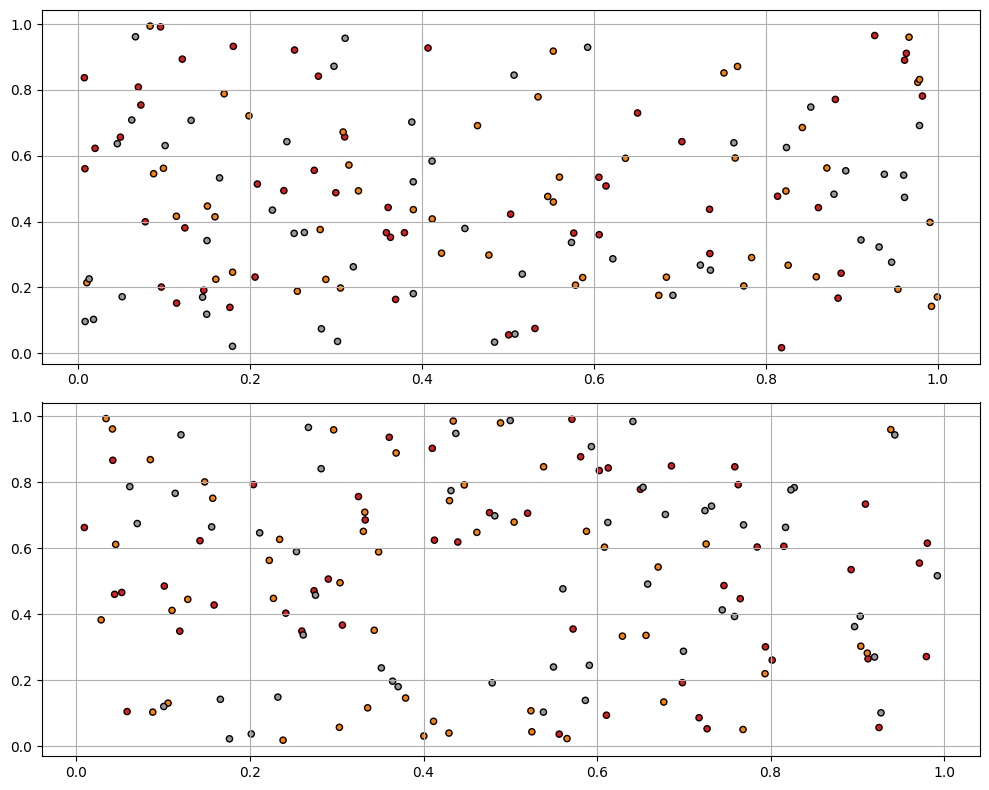

In [6]:
###
# code here
# replace x, y and x1, y1 with the values from your computed pca and your X
###
fig = plt.figure(1, figsize=(10, 8))
ax = plt.subplot(211)

#Plot scaled version
x, y = np.random.rand(2, 150)
g = plt.scatter(x, y, c = target, cmap = plt.cm.Set1, edgecolor = 'black', s = 20)
plt.grid()
plt.subplot(212)

# Plot principal components
x1, y1 = np.random.rand(2, 150)
plt.scatter(x1, y1, c = target,cmap = plt.cm.Set1, edgecolor = 'black', s = 20)
plt.grid()
plt.tight_layout()
plt.show()

## Explained Variance
The explained variance tells you how much information (variance) can be attributed to each of the principal components. 

By using the attribute `explained_variance_ratio_`, you can see that the first principal component explains 72.77% of the variance and the second principal component explains 23.03% of the variance.

In [7]:
print(pca.explained_variance_ratio_)

print(sum(pca.explained_variance_ratio_))

[0.72962445 0.22850762]
0.9581320720000166


So, in total our PCA has now expressed 96% of the variance of the dataset.
We can use these new components to attempt to fit an SVM like we did in the previous exercise. The lower dimensional data should retain most of the information in the original data and therefore should compete close to on par with a classifier trained on all features.

## Exercises
### 1) SVM
Apply an SVM to the principal components. How does it perform compared to using only two features per sample?

## 2) Three principal components
Attempt with three principal components. 
How much of the variance of the data do these express? 

Again, make a 3D plot where each point is colored respective to the predicted class from your SVM.

## 3) Best accuracy
Compare all the different SVM's we have trained. What is the best accuracy you can acheive?. You are also allowed to use different kernels!

## 4) Grid search
Attempt to perform a grid search with the function provided by `sklearn`.
The `gridsearch` function will try a lot of different combinations of parameters for your SVM so you don't have to.
```{Python}
from sklearn.model_selection import GridSearchCV
import numpy as np
    
c = np.logspace(start = -15, stop = 1000, base = 1.02)
param_grid = {'C': c}

grid = GridSearchCV(clf, param_grid = param_grid, cv = 3, n_jobs = -1, scoring = 'accuracy')
grid.fit(X_train, y_train)
```
[GridSearchCV documentation](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html)


Are you able to get a better fit?

=== Exercise 1: SVM on 2D PCA ===
SVC (RBF, PCA-2D) → Train = 0.946, Test = 0.895


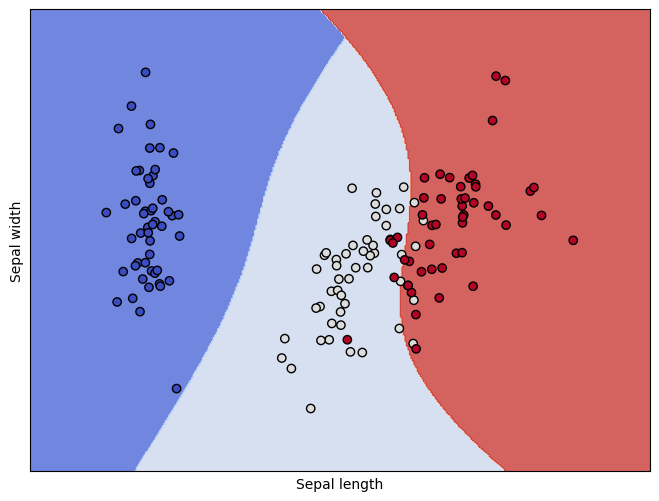

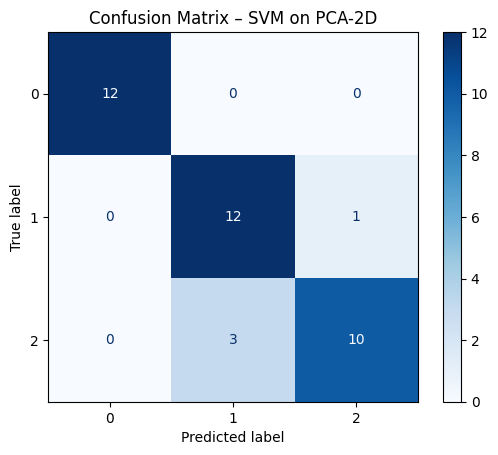


=== Exercise 2: SVM on 3D PCA ===
Explained variance ratio (3 PCs): [0.72962445 0.22850762 0.03668922]
Total variance explained: 0.9948212908928453
SVC (RBF, PCA-3D) → Train = 0.964, Test = 0.921


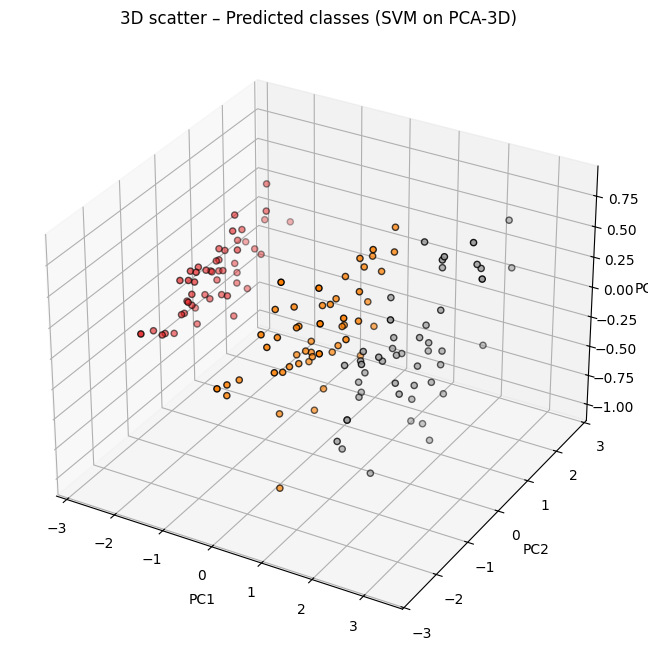


=== Exercise 3: Best Accuracy Comparison ===
SVC (RBF, all 4 features) → Train = 0.964, Test = 0.947

Summary of accuracies:
PCA-2D SVM : Train 0.946 | Test 0.895
PCA-3D SVM : Train 0.964 | Test 0.921
All 4D SVM : Train 0.964 | Test 0.947


In [8]:
###
# Exercises – PCA + SVM
###

from sklearn import svm
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, ConfusionMatrixDisplay
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt

# --- Exercise 1: SVM on 2D PCA ---
print("=== Exercise 1: SVM on 2D PCA ===")

# Use the 2D principal components computed earlier
X_pca2 = principalComponents  # from your PCA cell above

# Split into train/test
X_train, X_test, y_train, y_test = train_test_split(
    X_pca2, target, test_size=0.25, random_state=42, stratify=target
)

# Train an SVM with RBF kernel
svc_pca2 = svm.SVC(kernel="rbf", gamma="scale", C=1.0, random_state=0)
svc_pca2.fit(X_train, y_train)

train_acc = svc_pca2.score(X_train, y_train)
test_acc = svc_pca2.score(X_test, y_test)
print(f"SVC (RBF, PCA-2D) → Train = {train_acc:.3f}, Test = {test_acc:.3f}")

# Plot the decision surface
plot_fit(X_pca2, target, svc_pca2)

# Confusion matrix
ConfusionMatrixDisplay.from_estimator(svc_pca2, X_test, y_test, cmap="Blues")
plt.title("Confusion Matrix – SVM on PCA-2D")
plt.show()


# --- Exercise 2: SVM on 3D PCA ---
print("\n=== Exercise 2: SVM on 3D PCA ===")

from sklearn.decomposition import PCA
pca3 = PCA(n_components=3)
X_pca3 = pca3.fit_transform(X)

print("Explained variance ratio (3 PCs):", pca3.explained_variance_ratio_)
print("Total variance explained:", pca3.explained_variance_ratio_.sum())

X3_train, X3_test, y3_train, y3_test = train_test_split(
    X_pca3, target, test_size=0.25, random_state=42, stratify=target
)

svc_pca3 = svm.SVC(kernel="rbf", gamma="scale", C=1.0, random_state=0)
svc_pca3.fit(X3_train, y3_train)

train3 = svc_pca3.score(X3_train, y3_train)
test3 = svc_pca3.score(X3_test, y3_test)
print(f"SVC (RBF, PCA-3D) → Train = {train3:.3f}, Test = {test3:.3f}")

# 3D scatter of predicted classes
y3_pred = svc_pca3.predict(X_pca3)
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection="3d")
ax.scatter(
    X_pca3[:, 0], X_pca3[:, 1], X_pca3[:, 2],
    c=y3_pred, cmap=plt.cm.Set1, edgecolors="black"
)
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")
ax.set_title("3D scatter – Predicted classes (SVM on PCA-3D)")
plt.show()


# --- Exercise 3: Best Accuracy (compare all models) ---
print("\n=== Exercise 3: Best Accuracy Comparison ===")

# Compare PCA-2D vs PCA-3D vs all-features (4D)
X_train4, X_test4, y_train4, y_test4 = train_test_split(
    X, target, test_size=0.25, random_state=42, stratify=target
)

svc_full = svm.SVC(kernel="rbf", gamma="scale", C=1.0, random_state=0)
svc_full.fit(X_train4, y_train4)

train4 = svc_full.score(X_train4, y_train4)
test4 = svc_full.score(X_test4, y_test4)

print(f"SVC (RBF, all 4 features) → Train = {train4:.3f}, Test = {test4:.3f}")

print("\nSummary of accuracies:")
print(f"PCA-2D SVM : Train {train_acc:.3f} | Test {test_acc:.3f}")
print(f"PCA-3D SVM : Train {train3:.3f} | Test {test3:.3f}")
print(f"All 4D SVM : Train {train4:.3f} | Test {test4:.3f}")


Best params (PCA-2): {'C': np.float64(3.1622776601683795), 'gamma': np.float64(0.31622776601683794), 'kernel': 'rbf'}
Best CV accuracy (mean): 0.901
Held-out Test accuracy (PCA-2): 0.895


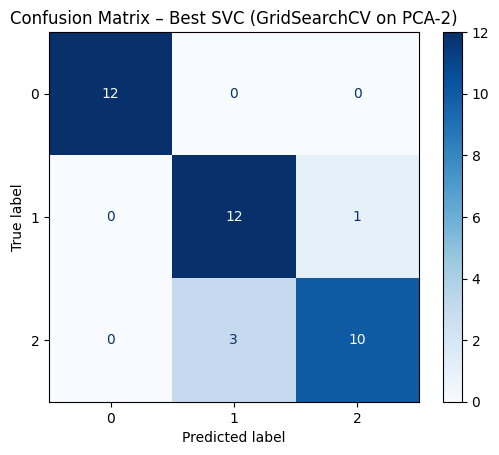

In [9]:
###
# Exercise 4: Grid search for SVM hyperparameters
###
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn import svm
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

# --- Use PCA(2) data from earlier step ---
# principalComponents -> X_pca2, target -> y
X_pca2 = principalComponents
y = target

# Split once to keep a proper held-out test set (CV stays inside train)
Xg_train, Xg_test, yg_train, yg_test = train_test_split(
    X_pca2, y, test_size=0.25, random_state=42, stratify=y
)

# Reasonable search ranges (compact, fast, and effective)
param_grid_pca2 = {
    "C": np.logspace(-2, 2, 9),        # 0.01 ... 100
    "gamma": np.logspace(-3, 1, 9),    # 0.001 ... 10
    "kernel": ["rbf"]
}

grid_pca2 = GridSearchCV(
    svm.SVC(random_state=0),
    param_grid=param_grid_pca2,
    cv=5,               # 5-fold stratified CV
    n_jobs=-1,
    scoring="accuracy"
)

grid_pca2.fit(Xg_train, yg_train)
print("Best params (PCA-2):", grid_pca2.best_params_)
print("Best CV accuracy (mean):", round(grid_pca2.best_score_, 3))

best_pca2 = grid_pca2.best_estimator_
print("Held-out Test accuracy (PCA-2):", round(best_pca2.score(Xg_test, yg_test), 3))

# Confusion matrix on the held-out test set
ConfusionMatrixDisplay.from_estimator(best_pca2, Xg_test, yg_test, cmap="Blues")
plt.title("Confusion Matrix – Best SVC (GridSearchCV on PCA-2)")
plt.show()
